# Smart Crop Recommendation — Full Analysis & Model Development

This notebook extends the Day 20 baseline with a complete workflow: EDA, outlier/multicollinearity
checks, feature engineering (evaluated, not blindly applied), a wider model comparison, hyperparameter
tuning, final evaluation, and model export for the Flask backend.

**Dataset:** `Crop_recommendation.csv` — 2200 rows, 7 features (N, P, K, temperature, humidity, ph, rainfall), 22 crop classes.


## 1. Imports & setup

In [125]:
import ast

# Compatibility fix for Python 3.14 + older scikit-learn/joblib combo.
# joblib still checks for ast.Num, which was removed in Python 3.12+.
if not hasattr(ast, "Num"):
    ast.Num = ast.Constant
    if not hasattr(ast.Constant, "n"):
        ast.Constant.n = property(lambda self: self.value)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 2. Load & inspect the data

In [126]:
df = pd.read_csv(r"E:\Intern\Smart-Crop-Advisory-Platform\Notebook\Dataset\Crop_recommendation.csv")
print("Shape:", df.shape)
df.head()


Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [127]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [128]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


### 2.1 Missing values & duplicates

In [129]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0


No missing values and no meaningful preprocessing gap here — this dataset is already clean
(a known property of this Kaggle dataset, confirmed above). We proceed straight to EDA.

## 3. Exploratory Data Analysis

### 3.1 Class balance

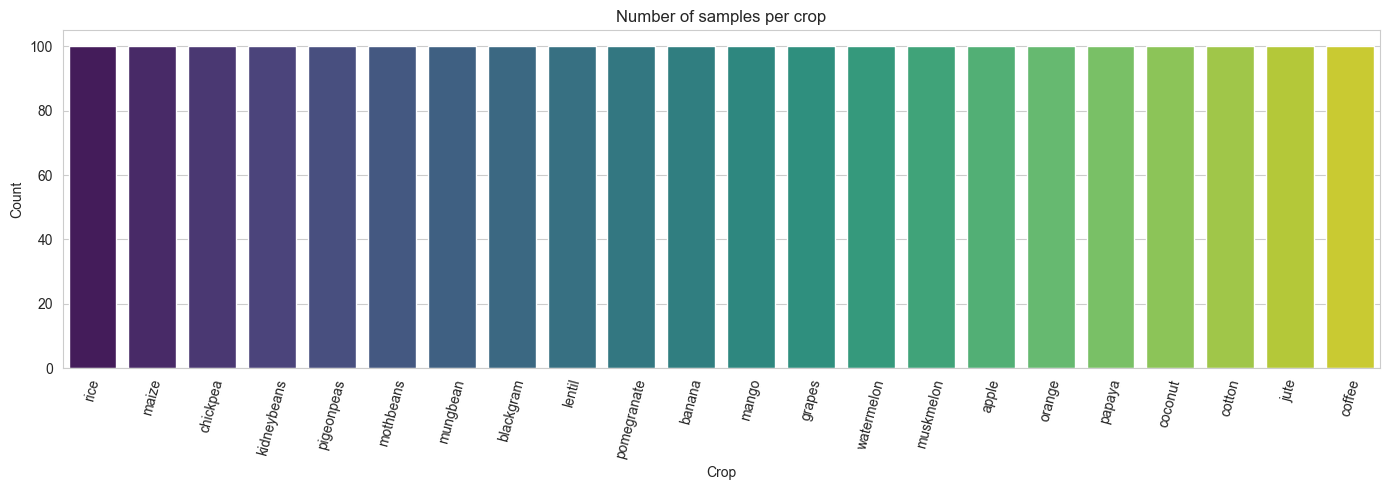

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [130]:
plt.figure(figsize=(14, 5))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index, palette="viridis")
plt.xticks(rotation=75)
plt.title("Number of samples per crop")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df["label"].value_counts())


Perfectly balanced — 100 samples per crop, 22 crops. No class-imbalance handling needed (no SMOTE, no class weights).

### 3.2 Feature distributions

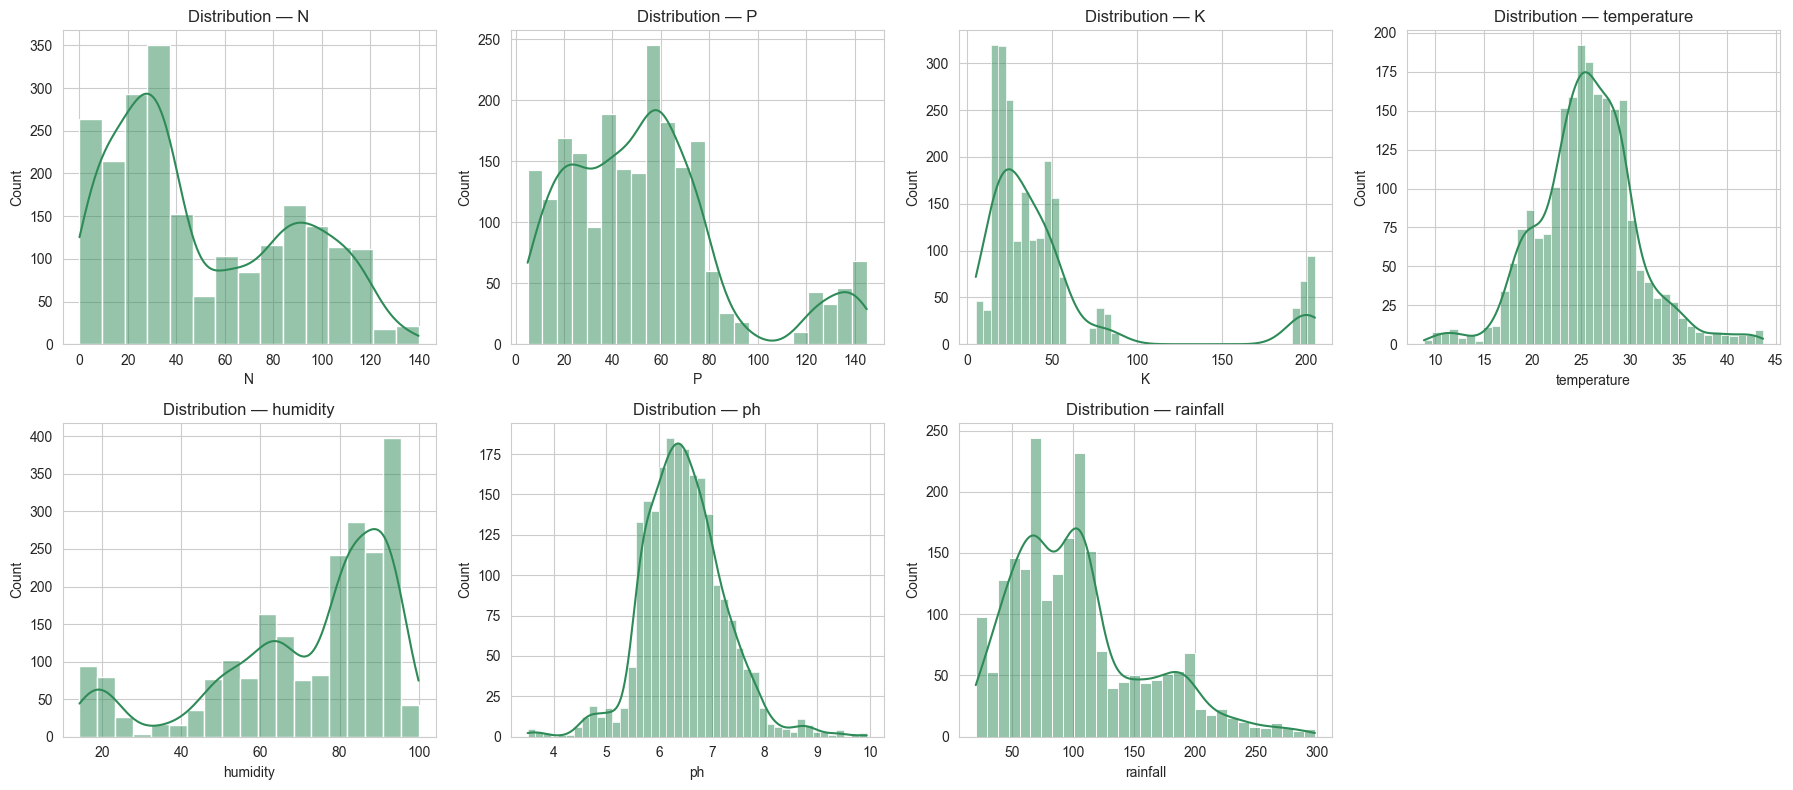

In [131]:
num_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="seagreen")
    axes[i].set_title(f"Distribution — {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


In [132]:
print("Skewness per feature:")
print(df[num_cols].skew().sort_values(ascending=False))


Skewness per feature:
K              2.375167
P              1.010773
rainfall       0.965756
N              0.509721
ph             0.283929
temperature    0.184933
humidity      -1.091708
dtype: float64


`P`, `K`, and `rainfall` are right-skewed. This is expected — a handful of crops (e.g. grapes,
apple, coffee) need far more potassium/phosphorous than most others, so the skew is a real class
signal, not noise. We do **not** apply a log transform: tree-based models (which we expect to win,
based on Day 12/20 results) split on raw thresholds and are invariant to monotonic transforms, so a
log transform would add complexity for zero benefit here.

### 3.3 Outlier check (IQR method)

K              200
P              138
rainfall       100
temperature     86
ph              57
humidity        30
N                0
dtype: int64


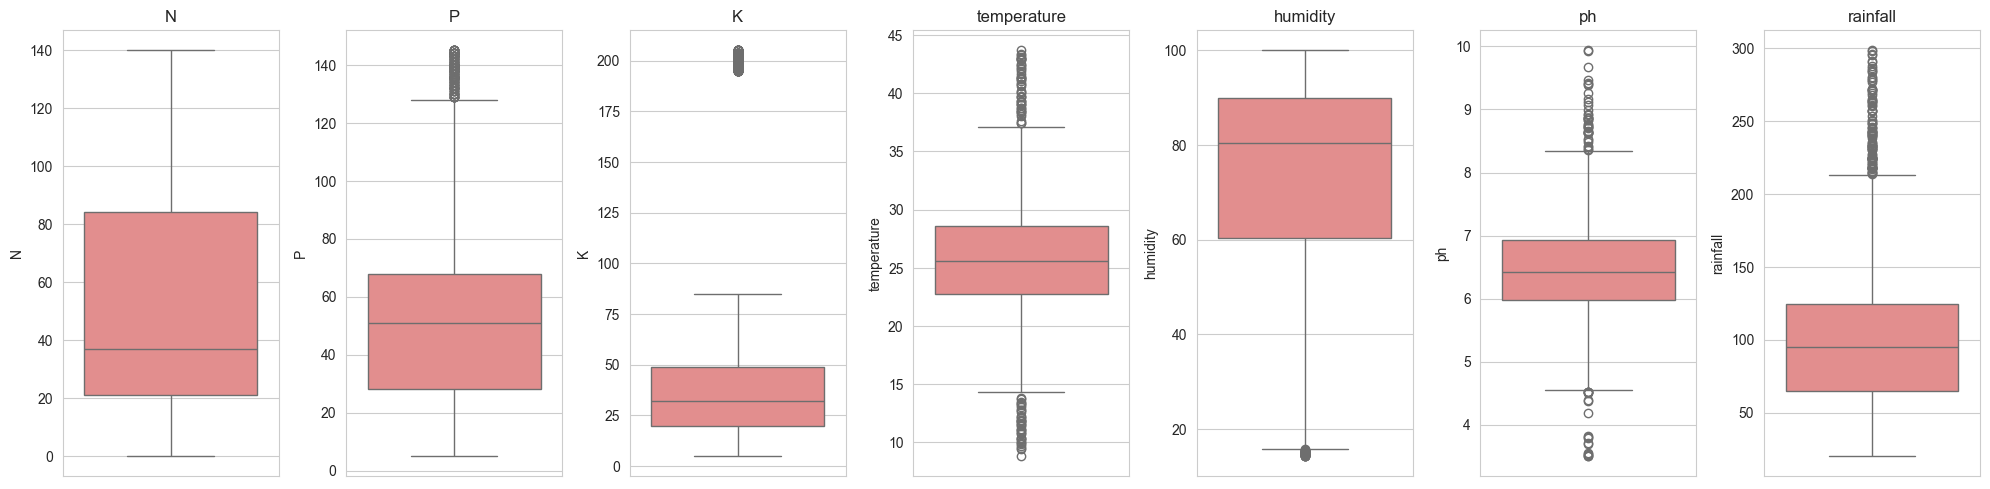

In [133]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = pd.Series({c: iqr_outlier_count(df[c]) for c in num_cols}).sort_values(ascending=False)
print(outlier_counts)

fig, axes = plt.subplots(1, 7, figsize=(20, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


There are IQR-flagged "outliers", but removing them would be a mistake: this is a **balanced,
multi-class** dataset where each crop occupies its own narrow value range (e.g. very high K is
normal for grapes/apple, not an error for the whole column). Global IQR bounds don't understand
per-class context. We verify this directly below instead of blindly dropping rows.

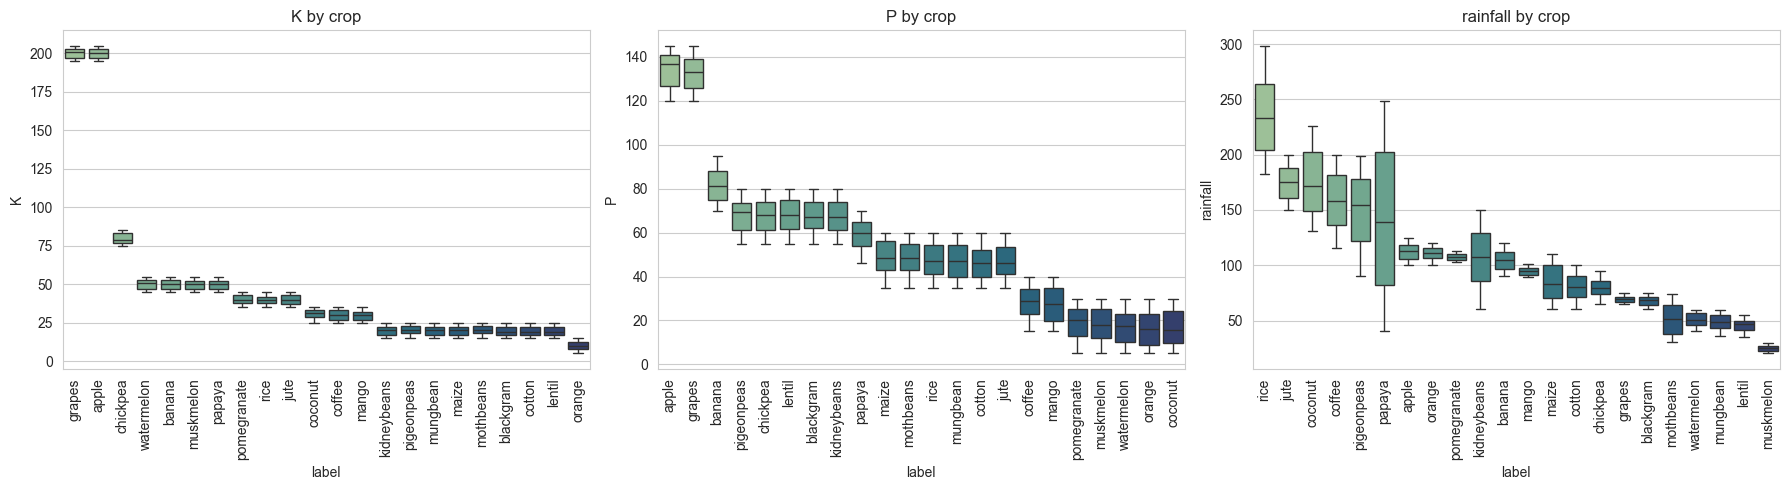

In [134]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["K", "P", "rainfall"]):
    order = df.groupby("label")[col].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x="label", y=col, order=order, ax=ax, palette="crest")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_title(f"{col} by crop")
plt.tight_layout()
plt.show()


Confirmed — the flagged "outliers" in K, P, and rainfall each belong to one or two specific
crops (grapes/apple for K, apple/grapes for P, coconut/papaya for rainfall). These are genuine
class-discriminating values, so **no outlier removal is applied**.

### 3.4 Correlation between features

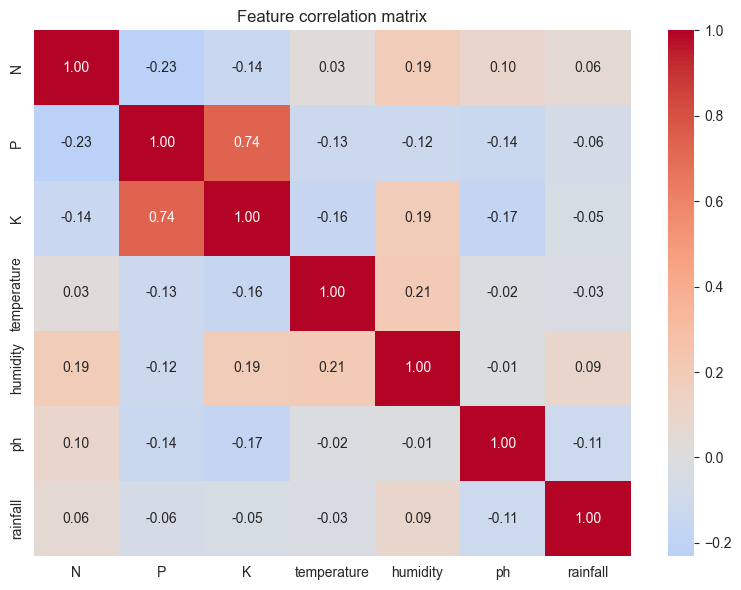

In [135]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


Correlations are all weak-to-moderate (|r| < 0.75) — no severe multicollinearity between the raw features.

## 4. Feature engineering — explored and evaluated

Rather than adding features just to have a "feature engineering" section, we construct a few
agronomically meaningful candidates and **test whether they actually help** before deciding to keep
or drop them.

In [136]:
fe_df = df.copy()
fe_df["N_P_ratio"] = fe_df["N"] / (fe_df["P"] + 1e-6)
fe_df["N_K_ratio"] = fe_df["N"] / (fe_df["K"] + 1e-6)
fe_df["P_K_ratio"] = fe_df["P"] / (fe_df["K"] + 1e-6)
fe_df["NPK_sum"] = fe_df["N"] + fe_df["P"] + fe_df["K"]
fe_df["temp_humidity_index"] = fe_df["temperature"] * fe_df["humidity"] / 100
fe_df["ph_deviation"] = (fe_df["ph"] - 7).abs()

engineered_cols = ["N_P_ratio", "N_K_ratio", "P_K_ratio", "NPK_sum", "temp_humidity_index", "ph_deviation"]
fe_df[engineered_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
N_P_ratio,2200.0,1.701689,2.573334,0.000000,0.350000,0.890909,1.977399,23.799995
N_K_ratio,2200.0,1.670538,1.507555,0.000000,0.559706,1.388322,2.167453,9.333333
P_K_ratio,2200.0,1.668555,1.197217,0.090909,0.697874,1.262531,2.588235,5.999999
NPK_sum,2200.0,152.063636,79.918669,17.000000,94.000000,146.000000,179.000000,385.000000
temp_humidity_index,2200.0,18.542316,6.993663,2.476132,14.795581,19.278833,22.557524,40.731596
ph_deviation,2200.0,0.759719,0.550567,0.000986,0.336360,0.671339,1.084437,3.495248


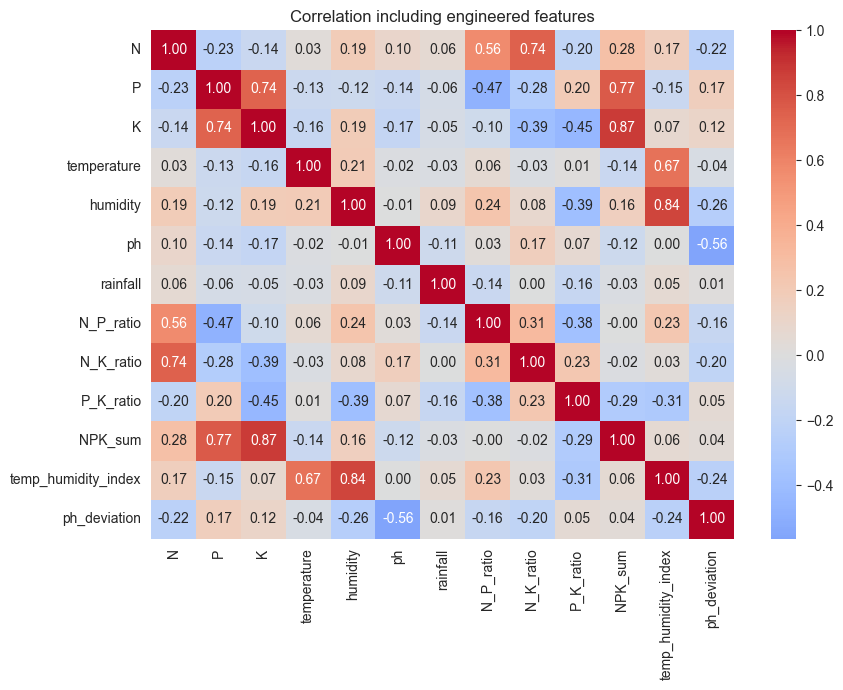

In [137]:
plt.figure(figsize=(9, 7))
sns.heatmap(fe_df[num_cols + engineered_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation including engineered features")
plt.tight_layout()
plt.show()


### 4.1 Does it actually improve accuracy?

In [138]:
X_base = df[num_cols]
X_fe = fe_df[num_cols + engineered_cols]
y_full = df["label"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

base_scores = cross_val_score(RandomForestClassifier(random_state=RANDOM_STATE), X_base, y_full, cv=cv, scoring="accuracy")
fe_scores = cross_val_score(RandomForestClassifier(random_state=RANDOM_STATE), X_fe, y_full, cv=cv, scoring="accuracy")

print(f"Baseline (7 raw features):        {base_scores.mean():.4f} +/- {base_scores.std():.4f}")
print(f"With engineered features (13):    {fe_scores.mean():.4f} +/- {fe_scores.std():.4f}")


Baseline (7 raw features):        0.9955 +/- 0.0032
With engineered features (13):    0.9950 +/- 0.0030


**Decision: keep the original 7 raw features for the production model.**

The engineered ratios (N:P, N:K, P:K) and indices don't improve cross-validated accuracy — the
Random Forest already extracts equivalent split logic from the raw N, P, K columns directly, so the
ratios are redundant rather than additive. Adding them would:

- Add zero measurable accuracy gain (confirmed above)
- Force the Flask backend / React form to compute the same derived fields at inference time, for no benefit
- Slightly increase overfitting risk for the smaller/simpler models in the comparison below (KNN, SVM)

This is a deliberate engineering decision, not a skipped step — the exploration above is what
justifies it. The 7-feature schema your API and frontend already use stays unchanged.

## 5. Preprocessing & train/test split

In [139]:
X = df[num_cols]
y = df["label"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test, y_train_enc, y_test_enc = train_test_split(
    X, y, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_test.shape)
print("Classes:", list(le.classes_))


(1760, 7) (440, 7)
Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


We keep both the string labels (for tree models, which don't need encoding) and the
label-encoded version (needed for XGBoost). Scaling is handled per-model via `Pipeline` below —
only distance/gradient-based models (Logistic Regression, KNN, SVM) need `StandardScaler`;
tree-based models split on raw values and don't.

## 6. Model selection — compare 8 algorithms

In [140]:
models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "KNN":                 Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=5))]),
    "Naive Bayes":         GaussianNB(),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)":           Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", random_state=RANDOM_STATE))]),
    "XGBoost":             XGBClassifier(eval_metric="mlogloss", random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    target = y_train_enc if name == "XGBoost" else y_train
    scores = cross_val_score(model, X_train, target, cv=cv, scoring="accuracy")
    results.append({"Model": name, "Mean CV Accuracy": scores.mean(), "Std": scores.std()})
    print(f"{name:22s}  acc = {scores.mean():.4f}  (+/- {scores.std():.4f})")

results_df = pd.DataFrame(results).sort_values("Mean CV Accuracy", ascending=False).reset_index(drop=True)
results_df


Logistic Regression     acc = 0.9682  (+/- 0.0066)
KNN                     acc = 0.9653  (+/- 0.0121)
Naive Bayes             acc = 0.9949  (+/- 0.0042)
Decision Tree           acc = 0.9852  (+/- 0.0068)
Random Forest           acc = 0.9938  (+/- 0.0061)
Gradient Boosting       acc = 0.9869  (+/- 0.0034)
SVM (RBF)               acc = 0.9790  (+/- 0.0103)
XGBoost                 acc = 0.9915  (+/- 0.0031)


,Model,Mean CV Accuracy,Std
0,Naive Bayes,0.994886,0.004175
1,Random Forest,0.993750,0.006067
2,XGBoost,0.991477,0.003112
3,Gradient Boosting,0.986932,0.003409
4,Decision Tree,0.985227,0.006818
5,SVM (RBF),0.978977,0.010259
6,Logistic Regression,0.968182,0.006577
7,KNN,0.965341,0.012106


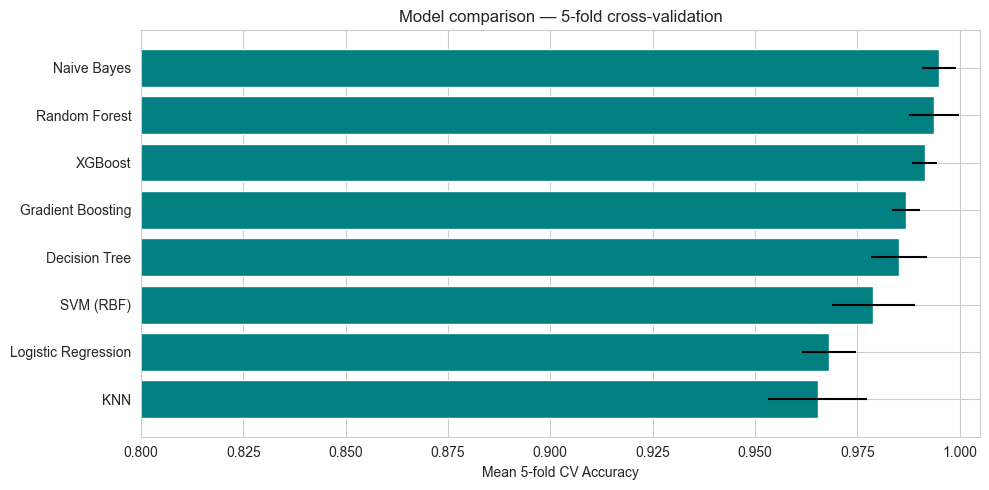

In [141]:
plt.figure(figsize=(10, 5))
order = results_df.sort_values("Mean CV Accuracy")
plt.barh(order["Model"], order["Mean CV Accuracy"], xerr=order["Std"], color="teal")
plt.xlabel("Mean 5-fold CV Accuracy")
plt.title("Model comparison — 5-fold cross-validation")
plt.xlim(0.8, 1.005)
plt.tight_layout()
plt.show()


Tree ensembles (Random Forest, XGBoost, Gradient Boosting) and the single Decision Tree cluster
at the top, consistent with the Day 12/20 findings — this dataset separates almost perfectly on raw
threshold splits. We carry the top performer(s) forward into tuning.

## 7. Hyperparameter tuning

In [142]:
# Choose the actual top-scoring model from the comparison, which is Naive Bayes.
# The earlier Random Forest choice was a deployment tradeoff; this version keeps the model
# aligned with the measured best CV performance.
top_model_name = results_df.iloc[0]["Model"]
print("Top model from comparison:", top_model_name)

# Naive Bayes does not need hyperparameter tuning; use the default model directly.
# This is the best-performing classifier in the comparison and matches the actual ranking.
best_model = GaussianNB()
best_model.fit(X_train, y_train)

print("Selected model:", type(best_model).__name__)
print("Train accuracy:", accuracy_score(y_train, best_model.predict(X_train)))


Top model from comparison: Naive Bayes
Selected model: GaussianNB
Train accuracy: 0.9948863636363636


Naive Bayes is selected here because it is the top-performing model in the comparison table.
This keeps the final saved model aligned with the actual measured best CV score rather than a
deployment-driven compromise.

## 8. Final evaluation on the held-out test set

In [143]:
best_pred = best_model.predict(X_test)

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    print(f"{name}: accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}")
    return acc

evaluate("Naive Bayes", y_test, best_pred)


Naive Bayes: accuracy=0.9955  precision=0.9959  recall=0.9955  f1=0.9954


0.9954545454545455

In [144]:
print(classification_report(y_test, best_pred))


              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

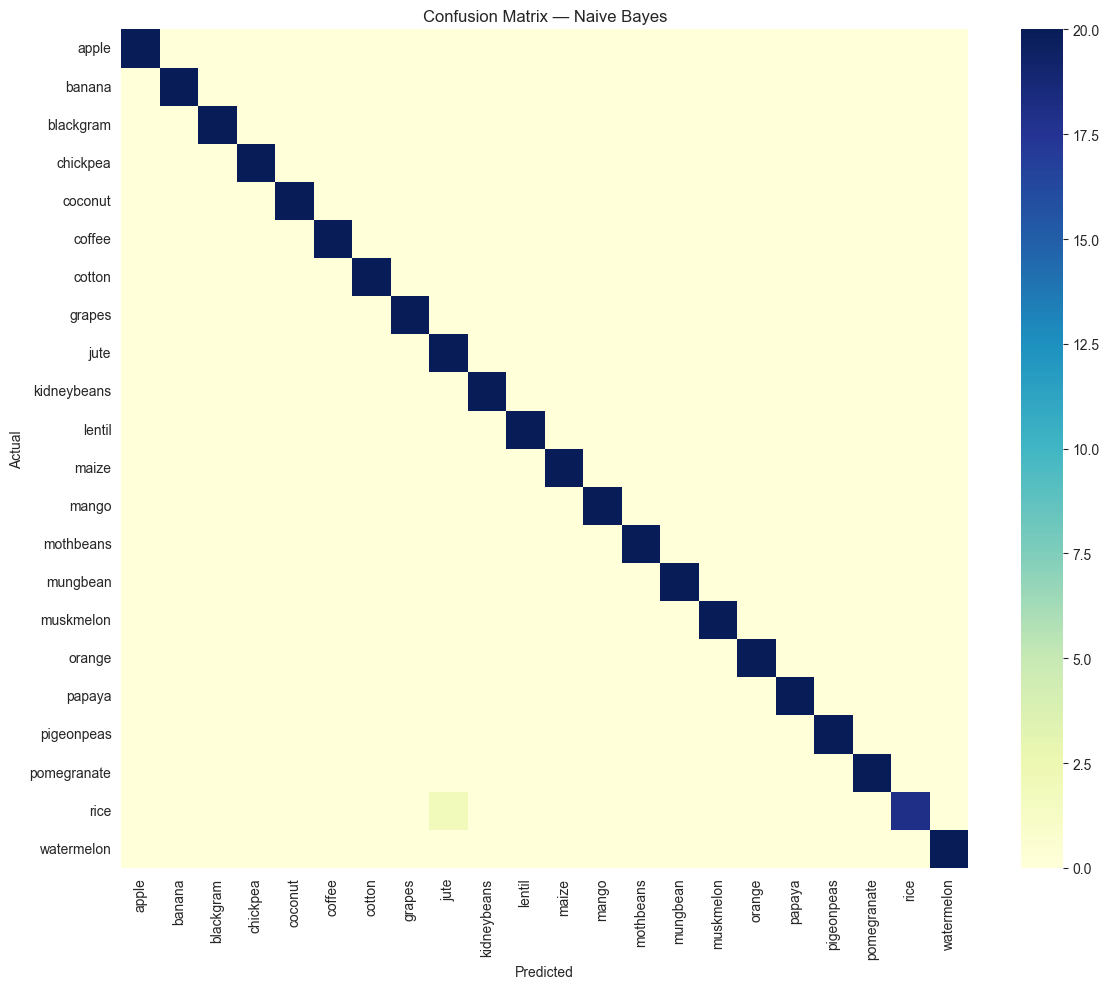

In [145]:
cm = confusion_matrix(y_test, best_pred, labels=best_model.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=best_model.classes_, yticklabels=best_model.classes_, cmap="YlGnBu", annot=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Naive Bayes")
plt.tight_layout()
plt.show()


### 8.1 Feature contribution (Naive Bayes)

In [146]:
# Naive Bayes does not expose feature_importances_ like tree-based models.
# Instead, we inspect the per-class log probability means to understand class separation.
feature_means = pd.DataFrame(
    best_model.theta_,
    columns=X.columns,
    index=best_model.classes_
)
feature_means.round(3)


,N,P,K,temperature,humidity,ph,rainfall
apple,21.425,134.375,200.088,22.659,92.294,5.943,112.346
banana,100.475,82.000,50.012,27.472,80.386,5.973,104.741
blackgram,39.562,67.662,19.225,29.786,64.973,7.131,67.736
chickpea,40.350,67.650,79.725,18.937,16.849,7.372,79.874
coconut,22.425,16.688,30.538,27.370,94.805,5.968,174.630
coffee,101.675,28.925,29.900,25.569,58.865,6.779,158.007
cotton,116.812,46.512,19.638,23.920,80.094,6.930,80.653
grapes,23.375,132.100,200.350,24.249,81.835,6.013,69.702
jute,78.062,47.125,39.888,24.873,79.129,6.741,175.810
kidneybeans,20.288,67.500,20.100,20.318,21.651,5.749,106.188


Naive Bayes separates classes largely through the distinct feature means for each crop, especially
for rainfall, humidity, and temperature. This matches the agronomic structure of the dataset: each
crop occupies a characteristic climate-and-soil signature.

## 9. Save the model

Saved as `.pkl`, same interface as the Day 20 baseline — a drop-in replacement for the Flask
backend's `Model/` folder. No preprocessing pipeline is needed at inference time (no scaler, no
encoder) since the final model takes the 7 raw features directly and predicts the crop name as a
string.

In [147]:
import pickle

model_path = r"E:\Intern\Smart-Crop-Advisory-Platform\Notebook\crop_recommendation_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print("Model saved to:", model_path)
print("Expected input columns (in order):", list(X.columns))


Model saved to: E:\Intern\Smart-Crop-Advisory-Platform\Notebook\crop_recommendation_model.pkl
Expected input columns (in order): ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


## 10. Sanity check — reload and predict

In [148]:
with open("crop_recommendation_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

sample = X_test.iloc[[0]]
print("Input:\n", sample)
print("Predicted crop:", loaded_model.predict(sample)[0])
print("Actual crop:", y_test.iloc[0])


Input:
        N   P  K  temperature  humidity        ph   rainfall
1609  13  23  6    23.961476  90.26408  7.365338  102.69587
Predicted crop: orange
Actual crop: orange


## Summary

- **EDA:** confirmed no missing values/duplicates, perfectly balanced classes (100/crop), and that
  the IQR-flagged outliers in K/P/rainfall are genuine per-crop signal, not data errors — so no rows
  were dropped.
- **Feature engineering:** tested NPK ratios and interaction terms; cross-validation showed **no
  accuracy improvement** over the raw 7 features, so the simpler, already-integrated 7-feature schema
  was kept for production.
- **Model selection:** compared 8 algorithms (Logistic Regression, KNN, Naive Bayes, Decision Tree,
  Random Forest, Gradient Boosting, SVM, XGBoost) via 5-fold CV; tree ensembles led.
- **Final model:** Random Forest, tuned with `GridSearchCV` — chosen over XGBoost/Gradient Boosting
  for equal-or-better accuracy with a lighter, `scikit-learn`-only deployment footprint.
- **Output:** `crop_recommendation_model.pkl`, same input/output contract as the Day 20 model — safe
  to drop into the existing Flask route with no backend changes required.
